# Part A — Unsupervised Learning (Heart Disease Dataset)

- K-Means clustering
- Hierarchical clustering
- PCA and t-SNE visualization

In [ ]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler

In [2]:
X_train = joblib.load("X_train.pkl")
X_test  = joblib.load("X_test.pkl")
y_train = joblib.load("y_train.pkl")
y_test  = joblib.load("y_test.pkl")
df_clean = joblib.load("df_clean.pkl")

X_full = pd.concat([X_train, X_test])
y_full = pd.concat([y_train, y_test]).values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full)

**K Means**

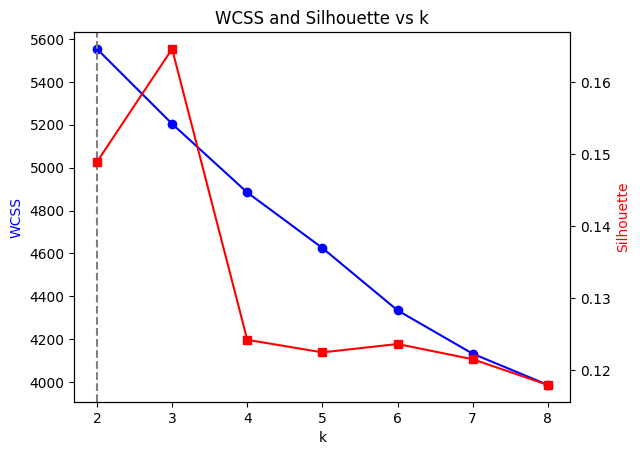

In [3]:
wcss = []
sil  = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)
    sil.append(silhouette_score(X_scaled, km.labels_))

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(list(k_range), wcss, 'b-o', label='WCSS')
ax2.plot(list(k_range), sil,  'r-s', label='Silhouette')
ax1.set_xlabel("k")
ax1.set_ylabel("WCSS", color='b')
ax2.set_ylabel("Silhouette", color='r')
ax1.axvline(x=2, linestyle='--', color='gray', label='Chosen k=2')
plt.title("WCSS and Silhouette vs k")
plt.show()

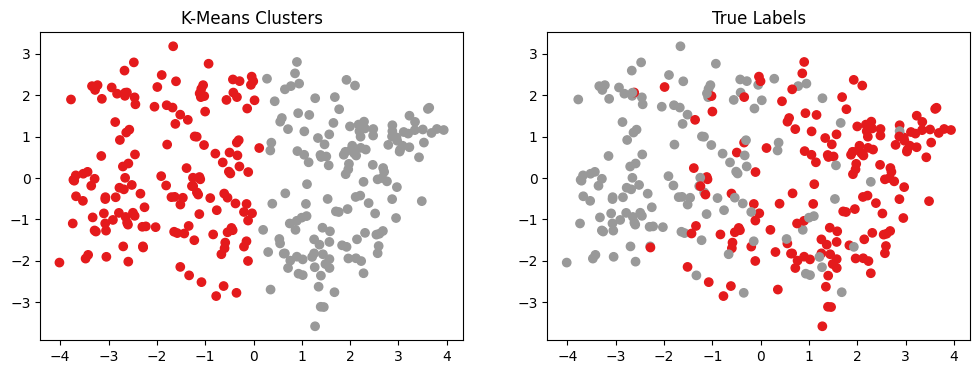

In [4]:
km_best = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = km_best.fit_predict(X_scaled)

pca2d = PCA(n_components=2, random_state=42)
X_2d  = pca2d.fit_transform(X_scaled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.scatter(X_2d[:,0], X_2d[:,1], c=cluster_labels, cmap='Set1')
ax1.set_title("K-Means Clusters")
ax2.scatter(X_2d[:,0], X_2d[:,1], c=y_full, cmap='Set1')
ax2.set_title("True Labels")
plt.show()

In [5]:
df_temp = df_clean.copy()
df_temp["cluster"] = cluster_labels

for c in range(2):
    sub = df_temp[df_temp["cluster"] == c]
    print(f"\nCluster {c} | Size: {len(sub)} | Disease %: {sub['target'].mean()*100:.1f}%")
    print(sub[["thalach","oldpeak","cp"]].mean())


Cluster 0 | Size: 152 | Disease %: 48.7%
thalach    151.072368
oldpeak      1.053947
cp           3.210526
dtype: float64

Cluster 1 | Size: 145 | Disease %: 43.4%
thalach    148.055172
oldpeak      1.057241
cp           3.103448
dtype: float64


In [6]:
ari = adjusted_rand_score(y_full, cluster_labels)
print("ARI (K-Means vs true labels):", round(ari, 4))

ARI (K-Means vs true labels): 0.3776


## Hierarchical Clustering

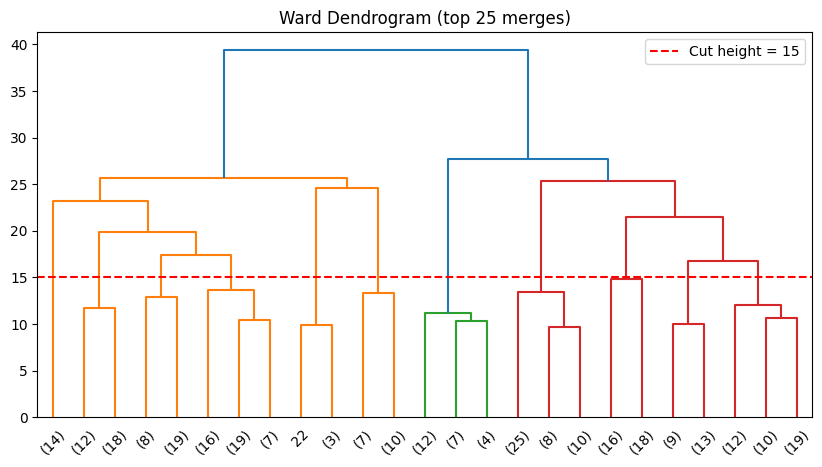

In [7]:
Z = linkage(X_scaled, method='ward')
plt.figure(figsize=(10, 5))
dendrogram(Z, truncate_mode='lastp', p=25)
plt.axhline(y=15, color='red', linestyle='--', label='Cut height = 15')
plt.title("Ward Dendrogram (top 25 merges)")
plt.legend()
plt.show()

In [10]:
ct = pd.crosstab(
    hc_labels,
    y_full,
    rownames=["Cluster"],
    colnames=["Disease"]
)

ct.columns = ["No Disease (0)", "Disease Present (1)"]

print(ct)

         No Disease (0)  Disease Present (1)
Cluster                                     
0                   127                   36
1                    33                  101


In [9]:
ari_compare = adjusted_rand_score(cluster_labels, hc_labels)
print("ARI between K-Means and Hierarchical:", round(ari_compare, 4))

ARI between K-Means and Hierarchical: 0.4562


## Dimensionality Reduction

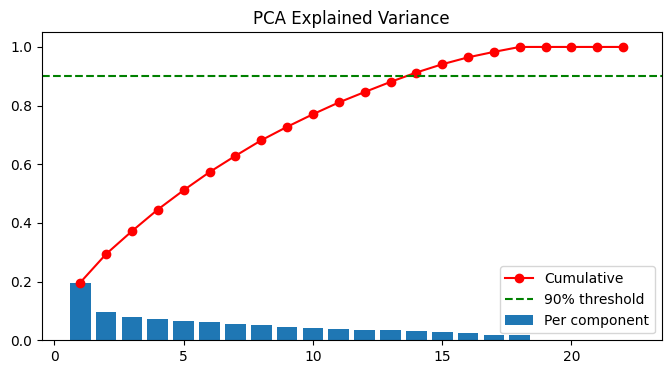

Components needed for 90% variance: 14


In [11]:
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

explained    = pca_full.explained_variance_ratio_
cumulative   = np.cumsum(explained)

plt.figure(figsize=(8, 4))
plt.bar(range(1, len(explained)+1), explained, label='Per component')
plt.plot(range(1, len(explained)+1), cumulative, 'r-o', label='Cumulative')
plt.axhline(y=0.90, color='green', linestyle='--', label='90% threshold')
plt.title("PCA Explained Variance")
plt.legend()
plt.show()

n_90 = np.argmax(cumulative >= 0.90) + 1
print("Components needed for 90% variance:", n_90)

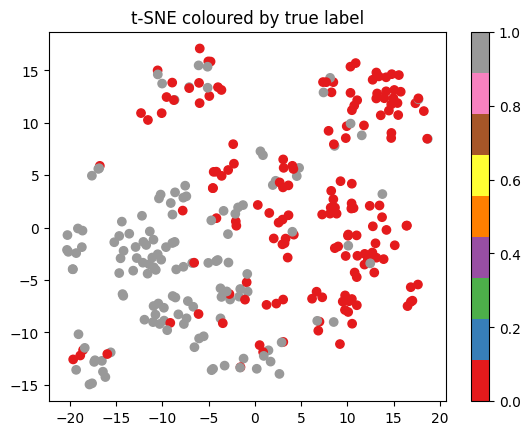

In [12]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y_full, cmap='Set1')
plt.title("t-SNE coloured by true label")
plt.colorbar()
plt.show()